In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Copy dataset zip from Drive to Colab workspace
!cp /content/drive/MyDrive/nn_dataset.zip /content/


In [ ]:
!ls /content | grep nn_dataset

nn_dataset.zip


In [ ]:
# Extract dataset
!unzip -q /content/nn_dataset.zip -d /content/nn_dataset

In [ ]:
!ls /content/nn_dataset
!ls /content/nn_dataset/Data

Data
best.pt  inference_vid.mp4  steering_wheel_image.jpg  train  val


In [ ]:
#count images
import os

train_images = [f for f in os.listdir("/content/nn_dataset/Data/train") if f.endswith(".jpg")]
val_images = [f for f in os.listdir("/content/nn_dataset/Data/val") if f.endswith(".jpg")]

print("Train images:", len(train_images))
print("Validation images:", len(val_images))

Train images: 20000
Validation images: 2000


In [ ]:
# Install YOLOv8 (Ultralytics implementation)
!pip install -q ultralytics

# Import YOLO class
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Load lightweight pretrained YOLOv8 nano model (trained on COCO dataset)
# This model will act as the perception module (object detector)
model = YOLO("yolov8n.pt")

In [ ]:
# Select a sample image from training set
sample_image_path = "/content/nn_dataset/Data/train/" + train_images[0]

# Run object detection with moderate confidence threshold
results = model(sample_image_path, conf=0.2)

# Print number of detected objects
print("Detections found:", len(results[0].boxes))


image 1/1 /content/nn_dataset/Data/train/5a2419f3-4fc0d689.jpg: 384x640 10 cars, 1 traffic light, 81.6ms
Speed: 11.7ms preprocess, 81.6ms inference, 47.3ms postprocess per image at shape (1, 3, 384, 640)
Detections found: 11


(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

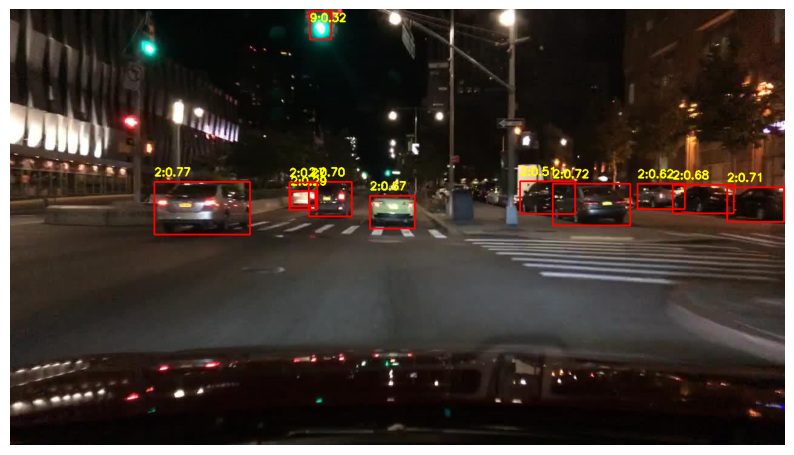

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load image
img = cv2.imread(sample_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Draw detected bounding boxes
for box in results[0].boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    conf = float(box.conf[0])
    cls_id = int(box.cls[0])

    # Draw rectangle
    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    # Display class ID and confidence
    cv2.putText(
        img,
        f"{cls_id}:{conf:.2f}",
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 0),
        2
    )

# Show image with detections
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")


In [ ]:
# COCO class IDs relevant to road risk
VEHICLE_CLASSES = [1, 2, 3, 5, 7]   # bicycle, car, motorcycle, bus, truck
PEDESTRIAN_CLASSES = [0]            # person


In [ ]:
import numpy as np
import cv2

def extract_features(image_path, model):
    """
    Runs YOLO detection, removes ego vehicle,
    and extracts contextual risk-related features.
    """

    # Run detection
    results = model(image_path, conf=0.2)
    boxes = results[0].boxes

    # Load image to get dimensions
    img = cv2.imread(image_path)
    img_h, img_w = img.shape[:2]

    # Ego filtering thresholds
    ego_y_thresh = int(img_h * 0.65)
    width_thresh = 0.6 * img_w
    area_thresh = 0.20 * img_h * img_w

    vehicle_count = 0
    pedestrian_count = 0
    bbox_areas = []

    # If detections exist
    if boxes is not None:
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls_id = int(box.cls[0])

            box_width = x2 - x1
            box_height = y2 - y1
            box_area = box_width * box_height

            # Ego vehicle check
            is_ego = (
                y1 > ego_y_thresh and
                (box_width > width_thresh or box_area > area_thresh)
            )

            if is_ego:
                continue  # skip ego detection

            # Count vehicles
            if cls_id in VEHICLE_CLASSES:
                vehicle_count += 1
                bbox_areas.append(box_area)

            # Count pedestrians
            if cls_id in PEDESTRIAN_CLASSES:
                pedestrian_count += 1
                bbox_areas.append(box_area)

    total_objects = vehicle_count + pedestrian_count

    # Compute contextual features
    object_density = total_objects / (img_h * img_w)
    avg_bbox_area = np.mean(bbox_areas) if bbox_areas else 0
    max_bbox_area = np.max(bbox_areas) if bbox_areas else 0

    return {
        "vehicle_count": vehicle_count,
        "pedestrian_count": pedestrian_count,
        "total_objects": total_objects,
        "object_density": object_density,
        "avg_bbox_area": avg_bbox_area,
        "max_bbox_area": max_bbox_area
    }


In [ ]:
features = extract_features(sample_image_path, model)
print(features)



image 1/1 /content/nn_dataset/Data/train/5a2419f3-4fc0d689.jpg: 384x640 10 cars, 1 traffic light, 14.2ms
Speed: 2.7ms preprocess, 14.2ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)
{'vehicle_count': 10, 'pedestrian_count': 0, 'total_objects': 10, 'object_density': 1.0850694444444445e-05, 'avg_bbox_area': np.float64(5201.1), 'max_bbox_area': np.int64(13746)}


In [ ]:
#testing ego filtering
test_image_path = "/content/nn_dataset/Data/train/000d4f89-3bcbe37a.jpg"

# Run detection
results = model(test_image_path, conf=0.2)

print("Raw detections:", len(results[0].boxes))



image 1/1 /content/nn_dataset/Data/train/000d4f89-3bcbe37a.jpg: 384x640 3 cars, 13.8ms
Speed: 6.2ms preprocess, 13.8ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)
Raw detections: 3


In [ ]:
features = extract_features(test_image_path, model)

print("After ego filtering (total_objects):", features["total_objects"])
print(features)



image 1/1 /content/nn_dataset/Data/train/000d4f89-3bcbe37a.jpg: 384x640 3 cars, 6.7ms
Speed: 1.7ms preprocess, 6.7ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
After ego filtering (total_objects): 2
{'vehicle_count': 2, 'pedestrian_count': 0, 'total_objects': 2, 'object_density': 2.170138888888889e-06, 'avg_bbox_area': np.float64(3459.0), 'max_bbox_area': np.int64(4410)}


In [ ]:
img = cv2.imread(test_image_path)
img_h, img_w = img.shape[:2]

ego_y_thresh = int(img_h * 0.65)
width_thresh = 0.6 * img_w
area_thresh = 0.20 * img_h * img_w

for box in results[0].boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    box_width = x2 - x1
    box_area = box_width * (y2 - y1)

    is_ego = (
        y1 > ego_y_thresh and
        (box_width > width_thresh or box_area > area_thresh)
    )

    print("Box:", [x1, y1, x2, y2], "→ Ego:", is_ego)


Box: [557, 360, 623, 398] → Ego: False
Box: [155, 326, 281, 361] → Ego: False
Box: [0, 537, 1214, 713] → Ego: True


In [ ]:
import torch
print(torch.cuda.is_available())


True


In [ ]:
import pandas as pd
from tqdm import tqdm

In [ ]:
import pandas as pd
from tqdm import tqdm
import os

output_file = "train_features.csv"

def process_batch(start_idx, batch_size=1000):

    train_feature_rows = []

    # Select only a slice of images
    batch_images = train_images[start_idx:start_idx + batch_size]

    print(f"Processing images {start_idx} to {start_idx + len(batch_images)}")

    # Loop over selected images
    for img_name in tqdm(batch_images):

        img_path = "/content/nn_dataset/Data/train/" + img_name

        # Extract contextual features
        features = extract_features(img_path, model)

        # Add image ID for traceability
        features["image_id"] = img_name

        train_feature_rows.append(features)

    # Convert list of dictionaries into DataFrame
    train_df = pd.DataFrame(train_feature_rows)

    # Append batch to CSV safely
    if not os.path.exists(output_file):
        train_df.to_csv(output_file, index=False)
    else:
        train_df.to_csv(output_file, mode='a', header=False, index=False)

    print("✅ Batch saved successfully.")

In [ ]:
process_batch(0, batch_size=1000)

Processing images 0 to 1000


  0%|          | 0/1000 [00:00<?, ?it/s]


image 1/1 /content/nn_dataset/Data/train/5a2419f3-4fc0d689.jpg: 384x640 10 cars, 1 traffic light, 8.7ms
Speed: 2.4ms preprocess, 8.7ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/397cfb2a-77707f3d.jpg: 384x640 3 cars, 6.1ms
Speed: 1.4ms preprocess, 6.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/740285bf-e568f563.jpg: 384x640 1 car, 6.5ms
Speed: 1.7ms preprocess, 6.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/59700f72-90902d09.jpg: 384x640 1 person, 6 cars, 1 bus, 1 truck, 5.9ms
Speed: 1.4ms preprocess, 5.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/afd05abf-0de7f963.jpg: 384x640 3 persons, 5 cars, 1 traffic light, 5.9ms
Speed: 1.5ms preprocess, 5.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


  0%|          | 5/1000 [00:00<00:22, 43.26it/s]


image 1/1 /content/nn_dataset/Data/train/55866155-39e0d627.jpg: 384x640 3 cars, 6.2ms
Speed: 1.4ms preprocess, 6.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/2439c8bb-ba2f46ef.jpg: 384x640 3 cars, 2 traffic lights, 6.2ms
Speed: 1.6ms preprocess, 6.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/89833bd3-70d9838f.jpg: 384x640 6 cars, 1 bus, 1 truck, 6.6ms
Speed: 1.8ms preprocess, 6.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/3bce0a5f-6b0c3495.jpg: 384x640 1 truck, 6.9ms
Speed: 2.0ms preprocess, 6.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/0cdaa475-100fd615.jpg: 384x640 6 cars, 2 buss, 2 trucks, 1 traffic light, 6.2ms
Speed: 1.6ms preprocess, 6.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


...


image 1/1 /content/nn_dataset/Data/train/acc1de50-0e723171.jpg: 384x640 8 cars, 3 traffic lights, 11.8ms
Speed: 2.6ms preprocess, 11.8ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/9e6550dd-f1ae6c96.jpg: 384x640 4 cars, 1 truck, 1 traffic light, 9.1ms
Speed: 2.1ms preprocess, 9.1ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/845de299-8311a5ba.jpg: 384x640 6 cars, 9.1ms
Speed: 1.8ms preprocess, 9.1ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/08119845-793c9e3a.jpg: 384x640 8 cars, 4 traffic lights, 9.4ms
Speed: 1.9ms preprocess, 9.4ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)


100%|█████████▉| 998/1000 [00:26<00:00, 35.43it/s]


image 1/1 /content/nn_dataset/Data/train/ac3d9758-dae6db02.jpg: 384x640 2 cars, 9 traffic lights, 11.5ms
Speed: 2.5ms preprocess, 11.5ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/02a0aa2f-0ba5cdab.jpg: 384x640 2 cars, 1 truck, 3 traffic lights, 8.5ms
Speed: 2.2ms preprocess, 8.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


100%|██████████| 1000/1000 [00:26<00:00, 37.34it/s]


✅ Batch saved successfully.


In [ ]:
!cp /content/train_features.csv /content/drive/MyDrive/train_features.csv

In [ ]:
!ls /content/drive/MyDrive | grep train_features

train_features.csv


In [ ]:
output_file = "/content/drive/MyDrive/train_features.csv"

In [ ]:
import pandas as pd

drive_csv_path = "/content/drive/MyDrive/train_features.csv"

df = pd.read_csv(drive_csv_path)
processed_count = len(df)

print("Already processed images:", processed_count)

Already processed images: 1000


In [ ]:
process_batch(processed_count, batch_size=1000)

Processing images 1000 to 2000


  0%|          | 0/1000 [00:00<?, ?it/s]


image 1/1 /content/nn_dataset/Data/train/98378ac5-6afa1ee9.jpg: 384x640 2 cars, 2 trucks, 12.7ms
Speed: 6.5ms preprocess, 12.7ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/57eb5bc1-8a5a605c.jpg: 384x640 5 cars, 7.0ms
Speed: 1.8ms preprocess, 7.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/2550d5cf-54664437.jpg: 384x640 3 cars, 5 traffic lights, 8.3ms
Speed: 1.8ms preprocess, 8.3ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


  0%|          | 3/1000 [00:00<00:33, 29.44it/s]


image 1/1 /content/nn_dataset/Data/train/528f2be0-3d6cd5b9.jpg: 384x640 5 cars, 7.5ms
Speed: 1.8ms preprocess, 7.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/6aa84d01-d017407b.jpg: 384x640 12 cars, 5 traffic lights, 6.9ms
Speed: 1.8ms preprocess, 6.9ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/aab38212-de4552a8.jpg: 384x640 6 cars, 2 traffic lights, 6.8ms
Speed: 1.8ms preprocess, 6.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/37a21a43-6e20964a.jpg: 384x640 15 cars, 1 truck, 7.1ms
Speed: 1.8ms preprocess, 7.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


...


image 1/1 /content/nn_dataset/Data/train/6f3343bd-c7a6371c.jpg: 384x640 1 person, 2 cars, 9.7ms
Speed: 1.9ms preprocess, 9.7ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/3fc48e12-b9ebae16.jpg: 384x640 13 cars, 6.6ms
Speed: 2.0ms preprocess, 6.6ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/024817df-f92d7680.jpg: 384x640 4 cars, 6.0ms
Speed: 1.4ms preprocess, 6.0ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/8dd19147-b4e535b3.jpg: 384x640 13 cars, 1 truck, 1 traffic light, 7.8ms
Speed: 1.9ms preprocess, 7.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


100%|█████████▉| 996/1000 [00:25<00:00, 37.39it/s]


image 1/1 /content/nn_dataset/Data/train/8b658f46-41978ba6.jpg: 384x640 5 cars, 1 bench, 8.9ms
Speed: 1.7ms preprocess, 8.9ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/9d55d5c8-4d59ec84.jpg: 384x640 7 persons, 5 cars, 1 airplane, 1 train, 8.0ms
Speed: 1.9ms preprocess, 8.0ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/28a1f566-4d2c84fd.jpg: 384x640 8 cars, 7.9ms
Speed: 1.8ms preprocess, 7.9ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/a52352ac-5b78ba8b.jpg: 384x640 5 cars, 8.8ms
Speed: 1.9ms preprocess, 8.8ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


100%|██████████| 1000/1000 [00:25<00:00, 38.53it/s]

✅ Batch saved successfully.


In [ ]:
len(pd.read_csv("/content/drive/MyDrive/train_features.csv"))

2000

In [ ]:
process_batch(2000, batch_size=1000)

Processing images 2000 to 3000


  0%|          | 0/1000 [00:00<?, ?it/s]


image 1/1 /content/nn_dataset/Data/train/383ce718-93682755.jpg: 384x640 5 cars, 8.5ms
Speed: 2.4ms preprocess, 8.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/8ee0a2fe-8887cd25.jpg: 384x640 6 cars, 2 traffic lights, 1 tv, 5.9ms
Speed: 1.4ms preprocess, 5.9ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/41ccdadb-46d0c2dd.jpg: 384x640 8 cars, 1 traffic light, 5.9ms
Speed: 1.4ms preprocess, 5.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/75daa538-dfa0f577.jpg: 384x640 8 cars, 1 truck, 6.2ms
Speed: 1.4ms preprocess, 6.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/3b3dadd8-8f3c8999.jpg: 384x640 2 cars, 1 traffic light, 5.9ms
Speed: 1.3ms preprocess, 5.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


  0%|          | 5/1000 [00:00<00:21, 45.68it/s]


image 1/1 /content/nn_dataset/Data/train/71b77915-c205f4ae.jpg: 384x640 4 cars, 6.0ms
Speed: 1.4ms preprocess, 6.0ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/1a7cc66f-1469cb04.jpg: 384x640 8 cars, 1 truck, 1 traffic light, 5.9ms
Speed: 1.4ms preprocess, 5.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/9c1467dc-6a1d958e.jpg: 384x640 4 cars, 3 traffic lights, 6.3ms
Speed: 1.4ms preprocess, 6.3ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/15248258-c2079874.jpg: 384x640 3 cars, 6.1ms
Speed: 1.4ms preprocess, 6.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/aa4a3c6c-2eee0908.jpg: 384x640 1 person, 5 cars, 4 traffic lights, 6.0ms
Speed: 1.4ms preprocess, 6.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


...


image 1/1 /content/nn_dataset/Data/train/5866bd5d-0505f61a.jpg: 384x640 1 person, 6 cars, 1 truck, 8.8ms
Speed: 2.0ms preprocess, 8.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/202132d1-5257585b.jpg: 384x640 10 cars, 1 traffic light, 7.7ms
Speed: 1.9ms preprocess, 7.7ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/6d7de47b-883e682c.jpg: 384x640 4 cars, 9.0ms
Speed: 1.9ms preprocess, 9.0ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/25ea4755-a9731665.jpg: 384x640 8 cars, 1 traffic light, 8.2ms
Speed: 1.7ms preprocess, 8.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


100%|█████████▉| 997/1000 [00:25<00:00, 32.65it/s]


image 1/1 /content/nn_dataset/Data/train/ac284a40-13d4dbe1.jpg: 384x640 17 cars, 1 traffic light, 10.8ms
Speed: 2.7ms preprocess, 10.8ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/6d8beed6-bc19880b.jpg: 384x640 8 cars, 10.1ms
Speed: 2.8ms preprocess, 10.1ms inference, 3.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/958e3a70-9861e1dd.jpg: 384x640 1 person, 12 cars, 1 truck, 8.4ms
Speed: 1.8ms preprocess, 8.4ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


100%|██████████| 1000/1000 [00:26<00:00, 38.45it/s]

✅ Batch saved successfully.


In [ ]:
len(pd.read_csv("/content/drive/MyDrive/train_features.csv"))

3000

In [ ]:
process_batch(3000, batch_size=5000)

Processing images 3000 to 8000


  0%|          | 0/5000 [00:00<?, ?it/s]


image 1/1 /content/nn_dataset/Data/train/4ec6eb8d-1c5529b8.jpg: 384x640 7 cars, 1 traffic light, 7.9ms
Speed: 2.2ms preprocess, 7.9ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/03a1130c-8c69a61a.jpg: 384x640 13 cars, 6.1ms
Speed: 1.5ms preprocess, 6.1ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/2059dcd1-26ad994d.jpg: 384x640 1 car, 5.9ms
Speed: 1.6ms preprocess, 5.9ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/0711ab13-ff3633ab.jpg: 384x640 1 person, 10 cars, 1 traffic light, 6.2ms
Speed: 1.6ms preprocess, 6.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/9cbdb85d-0455f218.jpg: 384x640 1 car, 6.1ms
Speed: 1.5ms preprocess, 6.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


  0%|          | 5/5000 [00:00<01:52, 44.47it/s]


image 1/1 /content/nn_dataset/Data/train/4581b7e0-c12d3de3.jpg: 384x640 3 cars, 2 traffic lights, 5.8ms
Speed: 1.4ms preprocess, 5.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/0a890a0f-637ac0b2.jpg: 384x640 2 cars, 5.9ms
Speed: 1.5ms preprocess, 5.9ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/9ec0b00e-de674d64.jpg: 384x640 2 cars, 6.0ms
Speed: 1.5ms preprocess, 6.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/0c1d07e3-0495b464.jpg: 384x640 2 persons, 1 car, 2 buss, 7.9ms
Speed: 1.5ms preprocess, 7.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/009aecce-ce4a9413.jpg: 384x640 23 cars, 1 bus, 2 trucks, 6.3ms
Speed: 1.4ms preprocess, 6.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


...


image 1/1 /content/nn_dataset/Data/train/6e096a56-354cba71.jpg: 384x640 6 cars, 7.0ms
Speed: 1.7ms preprocess, 7.0ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/1aa857d4-ece17742.jpg: 384x640 4 persons, 1 car, 2 traffic lights, 7.5ms
Speed: 1.9ms preprocess, 7.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/af0a17a2-2bb916c9.jpg: 384x640 12 cars, 1 truck, 8.6ms
Speed: 1.7ms preprocess, 8.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/039cb0e4-6c799a13.jpg: 384x640 1 person, 6 cars, 1 bus, 1 truck, 7.9ms
Speed: 1.9ms preprocess, 7.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/770da829-cc228b81.jpg: 384x640 8 cars, 8.5ms
Speed: 1.8ms preprocess, 8.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


100%|█████████▉| 4998/5000 [02:21<00:00, 39.93it/s]


image 1/1 /content/nn_dataset/Data/train/38ccfabc-e21f32fc.jpg: 384x640 10 cars, 2 buss, 1 traffic light, 8.5ms
Speed: 1.7ms preprocess, 8.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/20b07991-554011b3.jpg: 384x640 1 person, 7 cars, 1 bus, 1 stop sign, 7.8ms
Speed: 2.0ms preprocess, 7.8ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


100%|██████████| 5000/5000 [02:21<00:00, 35.36it/s]


✅ Batch saved successfully.


In [ ]:
len(pd.read_csv("/content/drive/MyDrive/train_features.csv"))

8000

In [ ]:
process_batch(8000, batch_size=2000)

Processing images 8000 to 10000


  0%|          | 0/2000 [00:00<?, ?it/s]


image 1/1 /content/nn_dataset/Data/train/3fd35391-efd9f0ec.jpg: 384x640 1 car, 2 trucks, 9.0ms
Speed: 2.5ms preprocess, 9.0ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/6fd5a4e8-eacc573b.jpg: 384x640 7 cars, 6.0ms
Speed: 1.6ms preprocess, 6.0ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/1ef13648-9bae0427.jpg: 384x640 10 cars, 1 traffic light, 5.8ms
Speed: 1.5ms preprocess, 5.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/4123a174-6d7a1093.jpg: 384x640 5 cars, 1 truck, 6.2ms
Speed: 1.5ms preprocess, 6.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/8e9e6281-4710e19e.jpg: 384x640 7 cars, 2 buss, 1 truck, 1 traffic light, 1 tv, 5.7ms
Speed: 1.4ms preprocess, 5.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


  0%|          | 5/2000 [00:00<00:44, 44.70it/s]


image 1/1 /content/nn_dataset/Data/train/99f8b03f-614a3c3c.jpg: 384x640 7 cars, 1 truck, 5.7ms
Speed: 1.4ms preprocess, 5.7ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/1e538e6d-01912fcc.jpg: 384x640 9 cars, 1 truck, 5.7ms
Speed: 1.3ms preprocess, 5.7ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/6a833008-7f5c7f85.jpg: 384x640 (no detections), 5.8ms
Speed: 1.4ms preprocess, 5.8ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/78485305-36e97b9f.jpg: 384x640 6 cars, 5.7ms
Speed: 1.4ms preprocess, 5.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/5b441ba8-7417e6f9.jpg: 384x640 8 cars, 2 traffic lights, 6.1ms
Speed: 1.4ms preprocess, 6.1ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/trai

...


image 1/1 /content/nn_dataset/Data/train/1598acd3-7c41770d.jpg: 384x640 7 cars, 8.5ms
Speed: 2.1ms preprocess, 8.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/680a82b6-76d5501c.jpg: 384x640 6 persons, 3 cars, 2 trucks, 1 fire hydrant, 2 umbrellas, 8.8ms
Speed: 2.0ms preprocess, 8.8ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/244ecdfa-9c263b68.jpg: 384x640 2 persons, 7 cars, 7.8ms
Speed: 2.0ms preprocess, 7.8ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/8e168ab8-71b120b3.jpg: 384x640 10 cars, 7.8ms
Speed: 1.8ms preprocess, 7.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


100%|█████████▉| 1998/2000 [00:56<00:00, 36.48it/s]


image 1/1 /content/nn_dataset/Data/train/2e1966c0-7894f3f0.jpg: 384x640 9 cars, 2 trucks, 7.9ms
Speed: 1.7ms preprocess, 7.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/nn_dataset/Data/train/553c3b79-62b93993.jpg: 384x640 13 cars, 8.0ms
Speed: 1.8ms preprocess, 8.0ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


100%|██████████| 2000/2000 [00:56<00:00, 35.67it/s]

✅ Batch saved successfully.


In [ ]:
len(pd.read_csv("/content/drive/MyDrive/train_features.csv"))

10000